Libraries Imported Successfully
Input Shape : torch.Size([100, 20])
Target Shape: torch.Size([100])
Two Models Created


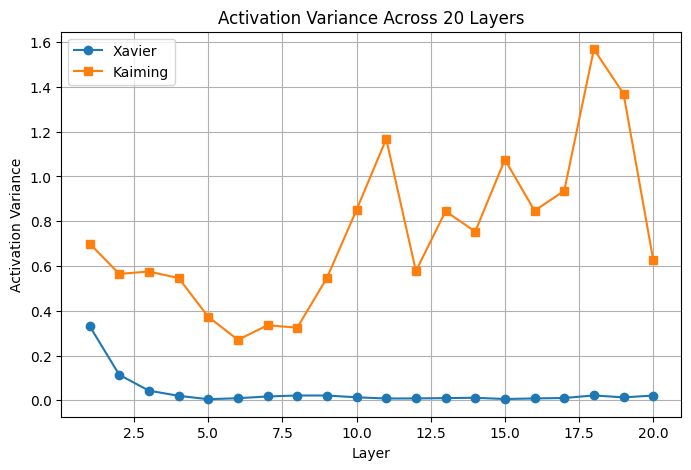


Xavier Gradient Values:
2e-06
2e-06
2e-06
2e-06
2e-06
2e-06
2e-06
2e-06
2e-06
2e-06

Kaiming Gradient Values:
0.004775
0.003894
0.003433
0.003154
0.002951
0.002761
0.002624
0.002612
0.002515
0.00243


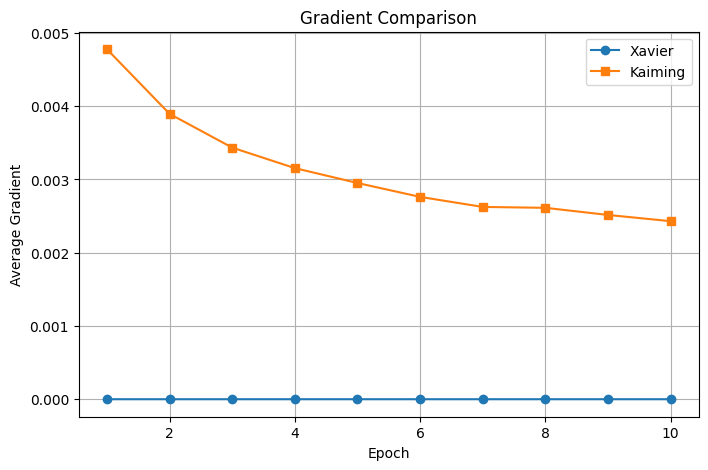


Experiment Completed
Xavier Final Gradient: 2e-06
Kaiming Final Gradient: 0.00243


In [1]:
# ==========================================================
# TASK 2
# Weight Initialization and Gradient Vanishing
# ==========================================================

# ----------------------------------------------------------
# Step 1 - Import Libraries
# ----------------------------------------------------------

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")


# ----------------------------------------------------------
# Step 2 - Create Deep Neural Network
# ----------------------------------------------------------

class DeepNetwork(nn.Module):

    def __init__(self, initialization):

        super(DeepNetwork, self).__init__()

        layers = []

        input_size = 20

        # Create 20 hidden layers
        for i in range(20):

            layer = nn.Linear(input_size, 20)

            if initialization == "xavier":

                nn.init.xavier_uniform_(layer.weight)

            elif initialization == "kaiming":

                nn.init.kaiming_uniform_(
                    layer.weight,
                    nonlinearity="relu"
                )

            layers.append(layer)
            layers.append(nn.ReLU())

            input_size = 20

        # Output layer
        output = nn.Linear(20, 2)

        layers.append(output)

        self.network = nn.Sequential(*layers)


    def forward(self, x):

        return self.network(x)


# ----------------------------------------------------------
# Step 3 - Create Input Data
# ----------------------------------------------------------

torch.manual_seed(42)

X = torch.randn(100, 20)

y = torch.randint(0, 2, (100,))


print("Input Shape :", X.shape)
print("Target Shape:", y.shape)


# ----------------------------------------------------------
# Step 4 - Create Models
# ----------------------------------------------------------

xavier_model = DeepNetwork("xavier")

kaiming_model = DeepNetwork("kaiming")


print("Two Models Created")


# ----------------------------------------------------------
# Step 5 - Calculate Activation Values
# ----------------------------------------------------------

def get_activations(model, X):

    activations = []

    x = X

    for layer in model.network:

        x = layer(x)

        if isinstance(layer, nn.ReLU):

            activations.append(
                x.detach().numpy()
            )

    return activations


# ----------------------------------------------------------
# Step 6 - Calculate Activation Statistics
# ----------------------------------------------------------

xavier_activations = get_activations(
    xavier_model,
    X
)

kaiming_activations = get_activations(
    kaiming_model,
    X
)


xavier_mean = []
xavier_variance = []

kaiming_mean = []
kaiming_variance = []


for activation in xavier_activations:

    xavier_mean.append(
        np.mean(activation)
    )

    xavier_variance.append(
        np.var(activation)
    )


for activation in kaiming_activations:

    kaiming_mean.append(
        np.mean(activation)
    )

    kaiming_variance.append(
        np.var(activation)
    )


# ----------------------------------------------------------
# Step 7 - Plot Activation Variance
# ----------------------------------------------------------

layers = range(1, 21)

plt.figure(figsize=(8, 5))

plt.plot(
    layers,
    xavier_variance,
    marker="o",
    label="Xavier"
)

plt.plot(
    layers,
    kaiming_variance,
    marker="s",
    label="Kaiming"
)

plt.xlabel("Layer")
plt.ylabel("Activation Variance")

plt.title("Activation Variance Across 20 Layers")

plt.legend()

plt.grid()

plt.show()


# ----------------------------------------------------------
# Step 8 - Training Function
# ----------------------------------------------------------

def train_model(model):

    loss_function = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.01
    )

    gradient_values = []

    for epoch in range(10):

        optimizer.zero_grad()

        output = model(X)

        loss = loss_function(output, y)

        loss.backward()

        # Store gradient of the first layer
        first_layer = model.network[0]

        gradient = first_layer.weight.grad

        gradient_values.append(
            gradient.abs().mean().item()
        )

        optimizer.step()

    return gradient_values


# ----------------------------------------------------------
# Step 9 - Train Both Models
# ----------------------------------------------------------

xavier_gradients = train_model(
    xavier_model
)

kaiming_gradients = train_model(
    kaiming_model
)


# ----------------------------------------------------------
# Step 10 - Display Gradient Values
# ----------------------------------------------------------

print("\nXavier Gradient Values:")

for value in xavier_gradients:

    print(round(value, 6))


print("\nKaiming Gradient Values:")

for value in kaiming_gradients:

    print(round(value, 6))


# ----------------------------------------------------------
# Step 11 - Plot Gradient Comparison
# ----------------------------------------------------------

epochs = range(1, 11)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    xavier_gradients,
    marker="o",
    label="Xavier"
)

plt.plot(
    epochs,
    kaiming_gradients,
    marker="s",
    label="Kaiming"
)

plt.xlabel("Epoch")
plt.ylabel("Average Gradient")

plt.title("Gradient Comparison")

plt.legend()

plt.grid()

plt.show()


# ----------------------------------------------------------
# Step 12 - Final Result
# ----------------------------------------------------------

print("\nExperiment Completed")

print(
    "Xavier Final Gradient:",
    round(xavier_gradients[-1], 6)
)

print(
    "Kaiming Final Gradient:",
    round(kaiming_gradients[-1], 6)
)